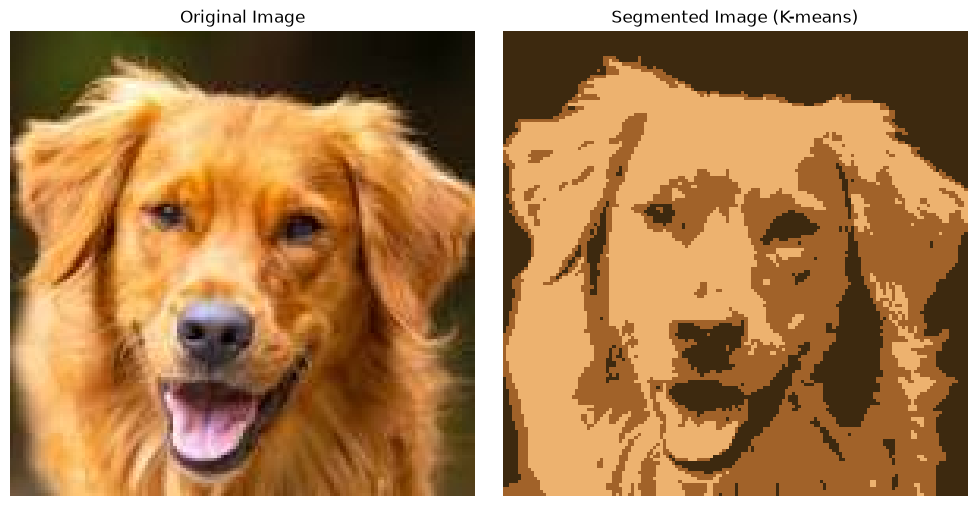

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('dog.jpeg')

if img is None:
    print("Error: Could not load image. Please check the file path.")
else:
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pixels = np.float32(rgb_img.reshape((-1, 3)))

    criteria = (
        cv2.TERM_CRITERIA_EPS +
        cv2.TERM_CRITERIA_MAX_ITER,
        100,
        0.2
    )

    K = 3

    _, labels, centers = cv2.kmeans(
        pixels,
        K,
        None,
        criteria,
        10,
        cv2.KMEANS_RANDOM_CENTERS
    )

    centers = np.uint8(centers)

    segmented_img = centers[
        labels.flatten()
    ].reshape(rgb_img.shape)

    plt.figure(figsize=(10, 5))

    plt.subplot(121)
    plt.imshow(rgb_img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(122)
    plt.imshow(segmented_img)
    plt.title('Segmented Image (K-means)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()